### Attention Map

- $ Q * K^T$: K에 존재하는 패치 j가 가지고 있는 정보를 Q에 존재하는 각 이미지 패치에 얼마나 전달하는지  정하는 것

- $AttentionRollout_L = (A_L + I) AttentionRollout_\text{L-1}$ 로 각 layer 마다의 Attention을 구함


- `Transformer` 구조 안에는 `residual connection`이 이미 있어서 원래는 자기 자신 정보가 유지되는데 `attention rollout`에서는 그 `residual`이 명시적으로 들어가 있지 않다.

- 따라서 자기 자신 정보가 사라질 수도 있기 때문에 $I$를 강제적으로 더해줘서 self정보를 사라지지 않게 한다


1. https://github.com/jacobgil/vit-explain
2. https://hongl.tistory.com/234

In [25]:
import torch
from torchvision import transforms
import numpy as np

import cv2
from PIL import Image
import matplotlib.pyplot as plt

In [26]:
model = torch.hub.load('facebookresearch/deit:main', 
'deit_tiny_patch16_224', pretrained=True)
model = model.cuda()

Using cache found in /home/qkboo/.cache/torch/hub/facebookresearch_deit_main


In [27]:
# [Issue]: result = torch.eye(attentions[0].size(-1)) problem #23 
#  Vit 구조 변경으로 인한 아래 코드 실행
for block in model.blocks:
    block.attn.fused_attn = False

In [28]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

img = Image.open('dogcat.jpeg')
img = img.resize((224,224))

input_tensor = transform(img).unsqueeze(0)
input_tensor = input_tensor.cuda()

In [33]:
class VITAttentionRollout:
    def __init__(self, model, attention_layer_name='attn_drop', head_fusion="mean", discard_ratio=0.9):
        self.model = model
        self.head_fusion = head_fusion
        self.discard_ratio = discard_ratio
        for name, module in self.model.named_modules():
            if attention_layer_name in name:
                # print(name)
                # print(module.__class__.__name__)
                module.register_forward_hook(self.get_attention)

        self.attentions = []

    def get_attention(self, module, input, output):
        print(f"[HOOK] module: {module.__class__.__name__}, output shape: {output.shape}")
        self.attentions.append(output.cpu())

    def __call__(self, input_tensor):
        self.attentions = []
        
        with torch.no_grad():
            output = self.model(input_tensor)
        print(f"Collected {len(self.attentions)} attention maps")
        return rollout(self.attentions, self.discard_ratio, self.head_fusion)

In [34]:
def rollout(attentions, discard_ratio, head_fusion):
    '''
    attentions: (1, 3, 197, 197) 크기의 텐서가 12개 담김
    3개인 이유는 Q, K, V로 나뉘기 때문
    '''
    result = torch.eye(attentions[0].size(-1)) # (197, 197) 단위 행렬
    with torch.no_grad():
        for attention in attentions:
            if head_fusion == "mean": # 여러 head를 하나로 합쳐서 해석하기 쉽게 만듦
                attention_heads_fused = attention.mean(axis=1)
            elif head_fusion == "max":
                attention_heads_fused = attention.max(axis=1)[0]
            elif head_fusion == "min":
                attention_heads_fused = attention.min(axis=1)[0]
            else:
                raise "Attention head fusion type Not supported"
                
            # class token을 날리지 않고 작은 attention 값을 제거하는 부분
            flat = attention_heads_fused.view(attention_heads_fused.size(0), -1) # (1, 197*197)
            _, indices = flat.topk(int(flat.size(-1) * discard_ratio), dim=-1, largest=False)  # topk: 상위 k개의 값을 가져오는 함수,  largest false: 가장 작은 값들을 가져옴
            indices = indices[indices != 0] # class token은 idx:0 위치해있어서 그걸 제외시킴
            flat[0, indices] = 0 # 작은 attention 값들을 0으로 제거

            I = torch.eye(attention_heads_fused.size(-1)) # (197, 197)
            a = (attention_heads_fused + 1.0 * I) / 2 #  자기 자신 정보를 추가로 더하여 강조
            a = a / a.sum(dim=-1) # normalization

            result = torch.matmul(a, result)  # [1, 197, 197] # 현재 attention과 이전까지의 누적 attention을 곱해서 누적함

    # Look at the total attention between the class token, and the image patches
    mask = result[0, 0, 1:]  # (196) 클래스 토큰이 이미지 패치 각각에 얼마나 집중했는지 하기 위하여 [0,0] 을 선택. class token을 제외한 나머지
    width = int(mask.size(-1) ** 0.5)
    mask = mask.reshape(width, width).numpy()
    mask = mask / np.max(mask) # 다시 normalization: 시각화할 때 편하게 보여주기 위함 (heatmap처럼)
    return mask  # (14, 14)

In [35]:
roll_out = VITAttentionRollout(model,head_fusion="mean", discard_ratio=0.9)

In [36]:
mask = roll_out(input_tensor)

[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 197])
[HOOK] module: Dropout, output shape: torch.Size([1, 3, 197, 1

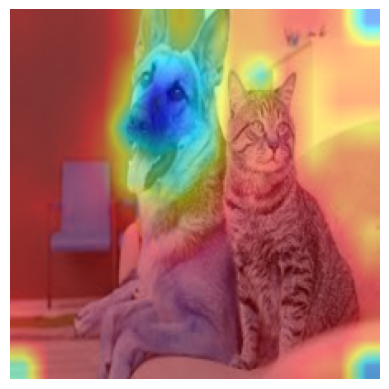

In [37]:
def show_mask_on_image(img, mask):
    img = np.float32(img) / 255
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

np_img = np.array(img)[:, :, ::-1]
mask = cv2.resize(mask, (np_img.shape[1], np_img.shape[0]))
mask = show_mask_on_image(np_img, mask)
plt.imshow(mask)
plt.axis('off')  # 축 제거 (선택)
plt.show()